# Indice Synthétique de Convergence Technologique — v5

## Journal des versions

| Version | Problème central | Correction |
|---------|-----------------|------------|
| v1 | C2 loading PCA = 1.000, indice plat à 0.5 | → abandon PCA |
| v2 | std(C2) >> std(C1), paires taxonomiques | → log-transform (insuffisant), filtre taxonomique |
| v3 | rank par année → série plate 0.42 | → rank globale |
| v4 | rank globale → série décroissante, C2 reliability=0.108 | → ΔJaccard, abandon C2 |
| **v5** | **double objectif contradictoire** | **→ deux modes distincts** |

## Architecture de la v5 : deux modes distincts

Le diagnostic de la v4 a révélé qu'un seul indice ne peut pas simultanément :
- Classer les paires à un instant t (qui converge le plus cette année ?)
- Montrer une tendance temporelle agrégée (l'espace technologique devient-il plus interconnecté ?)

La v5 sépare explicitement ces deux usages :

**MODE A — Classement des paires (rank par année)**
- Rank transform par année → distribution uniforme à chaque instant
- Identifie les paires anormalement convergentes par rapport à leurs pairs
- Usage : Top convergences, détection d'émergences technologiques

**MODE B — Série temporelle (panel cylindré)**
- Restreint aux paires présentes sur TOUTE la période (panel cylindré)
- Mesure l'évolution du Jaccard moyen sur un ensemble stable de paires
- Pas de biais de composition : les nouvelles paires n'entrent pas
- Usage : tendance macroscopique de la convergence technologique

## Autres corrections v5
1. **Abandon définitif de C2** : reliability moyenne = 0.108, contribution effective ≈ 1.6%
   Poids redistribués : C1=0.55, C3_delta=0.30, C4=0.15
2. **Lissage de ΔJaccard** : moyenne mobile sur 3 ans avant rank transform
   → réduit la volatilité de C3 (creux profonds sans justification économique en v4)
3. **Révision du ground truth C12N×A61K** : test de la rupture en 1988-1990
   plutôt qu'en 1995 (la co-occurrence biologie×pharmacie est antérieure)

## 0. Imports et paramètres

In [1]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# PARAMÈTRES
# ════════════════════════════════════════════════════════════════
WINDOW          = 5      # fenêtre glissante (années)
K_CLUSTERS      = 10
N_PCA_CLUST     = 20
YEAR_START      = 1980
YEAR_END        = 2022

# Filtres
MIN_PATENTS     = 30     # nb min de brevets/an par code
MIN_COOC        = 20     # nb min de co-occurrences sur la fenêtre

# ΔJaccard : lissage avant rank transform
# Justification : en v4, ΔJaccard oscillait fortement d'une année
# à l'autre (ex. creux à 0 en 2011 sur C12N×A61K sans raison économique)
# Une moyenne mobile sur 3 ans stabilise le signal tout en préservant
# la dynamique de moyen terme
DELTA_SMOOTH    = 3

# Panel cylindré : nb min d'années de présence pour MODE B
# Une paire doit être présente sur au moins MIN_YEARS_CYLINDRE années
# pour être incluse dans le panel cylindré
# Justification : on veut des paires stables sur toute la période
# pour mesurer l'évolution sans biais de composition
MIN_YEARS_CYLINDRE = 30  # présente sur au moins 30 des 43 années

# ── Poids v5 ────────────────────────────────────────────────────
# C2 abandonné définitivement (reliability=0.108, contribution≈1.6%)
# Son poids est redistribué sur C1 (+0.15) pour renforcer le signal
# le plus robuste
W = {
    'C1_jaccard' : 0.55,  # +0.15 vs v4 (récupère le poids de C2)
    'C3_delta'   : 0.30,  # inchangé
    'C4_cluster' : 0.15,  # inchangé
}

## 1. Chargement et préparation

In [2]:
df_raw = pd.read_parquet("multi_codes_brevets.parquet")
df_raw = df_raw.dropna(subset=["year", "cpc4_list"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

def normalize_cpc_list(lst):
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 3:
            clean.append(s[:4])
    return sorted(set(clean))

df_raw["cpc4"] = df_raw["cpc4_list"].apply(normalize_cpc_list)
df_raw = df_raw[df_raw["cpc4"].apply(len) >= 2].copy()

brevet_count_by_year = df_raw.groupby("year").size().to_dict()
N_mean = np.mean(list(brevet_count_by_year.values()))

print(f"Brevets : {len(df_raw):,} | Période : {df_raw['year'].min()}–{df_raw['year'].max()}")

Brevets : 1,234,382 | Période : 1980–2025


---
## C1 — Jaccard + filtre taxonomique (inchangé depuis v3)

In [3]:
def compute_jaccard_yearly(df, window=WINDOW, min_patents=MIN_PATENTS):
    years = sorted(df["year"].unique())
    records = []
    for t_center in years:
        df_w = df[(df["year"] >= t_center - window//2) &
                  (df["year"] <= t_center + window//2)]
        n_i  = Counter()
        n_ij = Counter()
        for _, row in df_w.iterrows():
            codes = row["cpc4"]
            for c in codes: n_i[c] += 1
            for ci, cj in itertools.combinations(codes, 2):
                n_ij[(min(ci,cj), max(ci,cj))] += 1
        for (ci, cj), cnt in n_ij.items():
            ni, nj = n_i[ci], n_i[cj]
            if ni < min_patents or nj < min_patents: continue
            union = ni + nj - cnt
            records.append({
                "cpc_i": ci, "cpc_j": cj, "year": t_center,
                "jaccard"     : cnt/union if union > 0 else 0,
                "p_j_given_i" : cnt/ni if ni > 0 else 0,
                "p_i_given_j" : cnt/nj if nj > 0 else 0,
                "n_cooc"      : cnt
            })
    return pd.DataFrame(records)


print("Calcul du Jaccard...")
df_jaccard = compute_jaccard_yearly(df_raw)
df_jaccard = df_jaccard[df_jaccard["n_cooc"] >= MIN_COOC].copy()
# filtre taxonomique
df_jaccard["px_i"] = df_jaccard["cpc_i"].str[:3]
df_jaccard["px_j"] = df_jaccard["cpc_j"].str[:3]
df_jaccard = df_jaccard[df_jaccard["px_i"] != df_jaccard["px_j"]].drop(columns=["px_i","px_j"]).copy()
print(f"  {len(df_jaccard):,} obs. après filtres")
print(f"  Jaccard mean={df_jaccard['jaccard'].mean():.4f}, std={df_jaccard['jaccard'].std():.4f}")

Calcul du Jaccard...
  165,484 obs. après filtres
  Jaccard mean=0.0202, std=0.0327


---
## C3 — ΔJaccard lissé

### Correction v5 : lissage par moyenne mobile sur DELTA_SMOOTH ans

En v4, ΔJaccard brut oscillait fortement d'une année à l'autre,
introduisant des creux profonds (C3_delta ≈ 0) sans justification
économique. Exemple : C12N×A61K avec C3_delta=0 en 2011 alors que
la convergence biopharma est continue.

Le lissage par moyenne mobile sur 3 ans stabilise le signal :
ΔJaccard_smooth(t) = moyenne(ΔJaccard(t-1), ΔJaccard(t), ΔJaccard(t+1))

Cela préserve la dynamique de moyen terme tout en éliminant
les oscillations purement statistiques.

Calcul de ΔJaccard lissé (C3 v5)...
  ΔJaccard brut  — std=0.00908
  ΔJaccard lissé — std=0.00850
  ΔJaccard > 0 (convergence) : 66,455
  ΔJaccard < 0 (divergence)  : 51,562


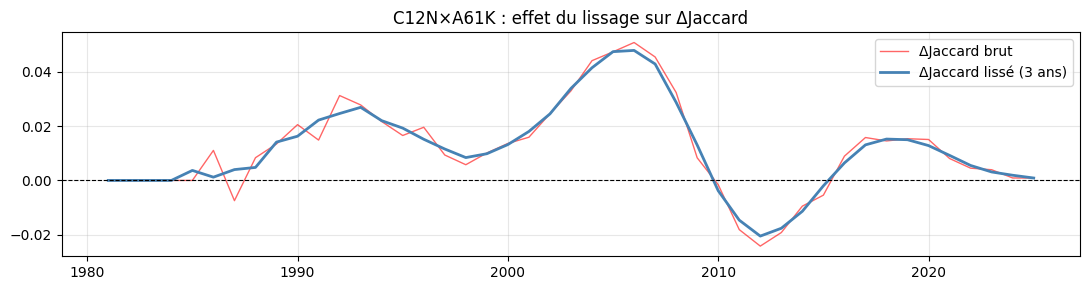

In [4]:
def compute_delta_jaccard_smooth(df_jaccard, window=WINDOW, smooth=DELTA_SMOOTH):
    """
    Calcule ΔJaccard lissé par moyenne mobile.
    Étapes :
    1. ΔJaccard(t) = Jaccard(t) - Jaccard(t-window)
    2. Lissage : moyenne mobile centrée sur 'smooth' années
    3. NaN → 0 (pas d'historique ou pas assez de points pour lisser)
    """
    df = df_jaccard.copy().sort_values(["cpc_i", "cpc_j", "year"])

    # ΔJaccard brut
    df_lag = df[["cpc_i","cpc_j","year","jaccard"]].copy()
    df_lag["year_future"] = df_lag["year"] + window
    df_lag = df_lag.rename(columns={"jaccard":"jaccard_lag","year":"year_lag"})
    df = df.merge(
        df_lag[["cpc_i","cpc_j","year_future","jaccard_lag"]],
        left_on=["cpc_i","cpc_j","year"],
        right_on=["cpc_i","cpc_j","year_future"],
        how="left"
    ).drop(columns=["year_future"])
    df["delta_jaccard_raw"] = (df["jaccard"] - df["jaccard_lag"]).fillna(0)

    # Lissage par moyenne mobile PAR PAIRE
    df = df.sort_values(["cpc_i","cpc_j","year"])
    df["delta_jaccard"] = (
        df.groupby(["cpc_i","cpc_j"])["delta_jaccard_raw"]
        .transform(lambda s: s.rolling(
            window=smooth,
            center=True,       # fenêtre centrée
            min_periods=2      # au moins 2 points pour lisser
        ).mean())
        .fillna(df["delta_jaccard_raw"])  # fallback sur brut si pas assez de points
    )

    return df


print("Calcul de ΔJaccard lissé (C3 v5)...")
df_jaccard = compute_delta_jaccard_smooth(df_jaccard)

print(f"  ΔJaccard brut  — std={df_jaccard['delta_jaccard_raw'].std():.5f}")
print(f"  ΔJaccard lissé — std={df_jaccard['delta_jaccard'].std():.5f}")
print(f"  ΔJaccard > 0 (convergence) : {(df_jaccard['delta_jaccard']>0).sum():,}")
print(f"  ΔJaccard < 0 (divergence)  : {(df_jaccard['delta_jaccard']<0).sum():,}")

# comparaison brut vs lissé sur un cas connu
mask = (
    ((df_jaccard["cpc_i"]=="C12N") & (df_jaccard["cpc_j"]=="A61K")) |
    ((df_jaccard["cpc_i"]=="A61K") & (df_jaccard["cpc_j"]=="C12N"))
)
sub = df_jaccard[mask].sort_values("year")
if len(sub) > 0:
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(sub["year"], sub["delta_jaccard_raw"], color="red",    lw=1,   alpha=0.6, label="ΔJaccard brut")
    ax.plot(sub["year"], sub["delta_jaccard"],     color="steelblue", lw=2, label=f"ΔJaccard lissé ({DELTA_SMOOTH} ans)")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_title("C12N×A61K : effet du lissage sur ΔJaccard")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## C4 — Cluster absorbant (inchangé depuis v4)

In [5]:
def build_cooc_matrix(df, year_start, year_end):
    df_w = df[(df["year"] >= year_start) & (df["year"] <= year_end)]
    df_w = df_w[df_w["cpc4"].apply(lambda x: len(x) >= 2)]
    pair_counter = Counter()
    for cpcs in df_w["cpc4"]:
        for ci, cj in itertools.combinations(sorted(set(cpcs)), 2):
            pair_counter[(ci,cj)] += 1
            pair_counter[(cj,ci)] += 1
    cooc = pd.DataFrame(
        [(i,j,c) for (i,j),c in pair_counter.items()],
        columns=["cpc_i","cpc_j","count"]
    )
    row_sums = cooc.groupby("cpc_i")["count"].sum().rename("row_sum")
    cooc = cooc.join(row_sums, on="cpc_i")
    cooc["M_ij"] = cooc["count"] / cooc["row_sum"]
    return cooc


print("Clustering dynamique...")
pca_clust  = PCA(n_components=N_PCA_CLUST, random_state=0)
kmeans_obj = KMeans(n_clusters=K_CLUSTERS, random_state=0, n_init=10)
cluster_time = []
for start in range(YEAR_START, YEAR_END - WINDOW + 2):
    end = start + WINDOW - 1
    cooc_w = build_cooc_matrix(df_raw, start, end)
    if len(cooc_w) == 0: continue
    M_w = cooc_w.pivot(index="cpc_i", columns="cpc_j", values="M_ij").fillna(0)
    if M_w.shape[0] < N_PCA_CLUST: continue
    clusters = kmeans_obj.fit_predict(pca_clust.fit_transform(M_w))
    cluster_time.append(pd.DataFrame({
        "cpc": M_w.index, "cluster": clusters, "year": start + WINDOW//2
    }))
cluster_time_df = pd.concat(cluster_time, ignore_index=True)
print(f"  {cluster_time_df['year'].nunique()} années")

def entropy_fn(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

df_cl = cluster_time_df.sort_values(["cpc","year"]).copy()
transitions = []
for cpc, sub in df_cl.groupby("cpc"):
    sub = sub.sort_values("year")
    for i in range(len(sub)-1):
        transitions.append({
            "cpc":cpc,
            "year_t":sub.iloc[i]["year"],   "year_t1":sub.iloc[i+1]["year"],
            "cluster_t":sub.iloc[i]["cluster"], "cluster_t1":sub.iloc[i+1]["cluster"]
        })
trans_df = pd.DataFrame(transitions)

inflow = (
    trans_df.groupby(["year_t1","cluster_t1"])["cluster_t"]
    .value_counts(normalize=True).rename("p").reset_index()
)
inflow_H = inflow.groupby(["year_t1","cluster_t1"])["p"].apply(entropy_fn).reset_index(name="H_in")
persist  = (
    trans_df.groupby(["year_t","cluster_t"])
    .apply(lambda x: np.mean(x["cluster_t1"]==x["cluster_t"]))
    .reset_index(name="persistence")
)
absorption_df = inflow_H.merge(
    persist, left_on=["year_t1","cluster_t1"], right_on=["year_t","cluster_t"], how="left"
).drop(columns=["year_t","cluster_t"])
absorption_df = absorption_df.rename(columns={"year_t1":"year","cluster_t1":"cluster"})
absorption_df["absorption_score"] = absorption_df["H_in"] * absorption_df["persistence"].fillna(0)
H_thresh = absorption_df["H_in"].quantile(0.75)
P_thresh = absorption_df["persistence"].quantile(0.75)
absorption_df["is_absorbing"] = (
    (absorption_df["H_in"] >= H_thresh) & (absorption_df["persistence"] >= P_thresh)
)

cluster_lookup = cluster_time_df.set_index(["cpc","year"])["cluster"].to_dict()
absorb_lookup  = absorption_df.set_index(["year","cluster"])["absorption_score"].to_dict()

df_c4 = df_jaccard[["cpc_i","cpc_j","year"]].copy()
def row_c4(r):
    cl_i = cluster_lookup.get((r["cpc_i"],r["year"]))
    cl_j = cluster_lookup.get((r["cpc_j"],r["year"]))
    if cl_i is None or cl_j is None or cl_i != cl_j: return 0.0
    return absorb_lookup.get((r["year"],cl_i), 0.0)
df_c4["cluster_absorption"] = df_c4.apply(row_c4, axis=1)
print(f"  {(df_c4['cluster_absorption']>0).sum():,} paires absorbantes ({100*(df_c4['cluster_absorption']>0).mean():.1f}%)")

Clustering dynamique...
  39 années
  24,480 paires absorbantes (14.8%)


---
## Assemblage du panel complet

In [6]:
keys = ["cpc_i","cpc_j","year"]

panel = (
    df_jaccard[[
        "cpc_i","cpc_j","year","jaccard",
        "delta_jaccard","delta_jaccard_raw","jaccard_lag",
        "p_j_given_i","p_i_given_j","n_cooc"
    ]]
    .merge(df_c4, on=keys, how="left")
)
panel["cluster_absorption"] = panel["cluster_absorption"].fillna(0)
panel = panel[panel["year"] <= YEAR_END].copy()

print(f"Panel complet : {len(panel):,} lignes | {panel['year'].nunique()} années")
print(f"Codes uniques : {pd.concat([panel['cpc_i'],panel['cpc_j']]).nunique()}")

Panel complet : 145,843 lignes | 43 années
Codes uniques : 598


---
## Normalisation : deux modes distincts

### MODE A — Rank par année (classement des paires)
Chaque composante est rankée PAR ANNÉE.
→ Identifie les paires anormalement convergentes à chaque instant
→ La série temporelle agrégée sera plate (par construction) — c'est normal,
   ce mode n'est PAS conçu pour montrer des tendances

### MODE B — Panel cylindré (série temporelle)
Restreint aux paires présentes sur MIN_YEARS_CYLINDRE années minimum.
Mesure l'évolution du Jaccard MOYEN sur cet ensemble stable.
→ Pas de biais de composition
→ Tendance macroscopique interprétable économiquement

In [7]:
# ════════════════════════════════════════════════════════════════
# MODE A : rank par année
# ════════════════════════════════════════════════════════════════

def rank_by_year(df, col):
    return df.groupby("year")[col].rank(method="average", pct=True)

panel["C1_A"] = rank_by_year(panel, "jaccard")
panel["C3_A"] = rank_by_year(panel, "delta_jaccard")

# C4 : rank par année uniquement sur paires absorbantes
panel["C4_A"] = 0.0
mask_abs = panel["cluster_absorption"] > 0
if mask_abs.sum() > 0:
    panel.loc[mask_abs, "C4_A"] = (
        panel[mask_abs]
        .groupby("year")["cluster_absorption"]
        .rank(method="average", pct=True)
    )

# Indice MODE A
panel["CI_A"] = sum(W[col.replace('_A','').replace('C1','C1').replace('C3','C3').replace('C4','C4')]
                   * panel[col] for col in ['C1_A','C3_A','C4_A']
                   if col.replace('_A','') in
                   ['C1_jaccard','C3_delta','C4_cluster'])

# version propre
panel["CI_A"] = (
    W['C1_jaccard'] * panel["C1_A"] +
    W['C3_delta']   * panel["C3_A"] +
    W['C4_cluster'] * panel["C4_A"]
)
panel["CI_A"] = (
    (panel["CI_A"] - panel["CI_A"].min()) /
    (panel["CI_A"].max() - panel["CI_A"].min())
)

print("MODE A stats :")
print(panel[["C1_A","C3_A","C4_A","CI_A"]].describe().round(4))

MODE A stats :
              C1_A         C3_A         C4_A         CI_A
count  145843.0000  145843.0000  145843.0000  145843.0000
mean        0.5001       0.5001       0.0840       0.4249
std         0.2887       0.2813       0.2102       0.2034
min         0.0001       0.0001       0.0000       0.0000
25%         0.2501       0.2610       0.0000       0.2593
50%         0.5001       0.4602       0.0000       0.4073
75%         0.7502       0.7451       0.0000       0.5676
max         1.0000       1.0000       0.9990       1.0000


In [8]:
# ════════════════════════════════════════════════════════════════
# MODE B : panel cylindré
# ════════════════════════════════════════════════════════════════

# Identifier les paires présentes sur au moins MIN_YEARS_CYLINDRE années
years_per_pair = (
    panel.groupby(["cpc_i","cpc_j"])["year"]
    .nunique()
    .reset_index(name="n_years")
)
stable_pairs = years_per_pair[
    years_per_pair["n_years"] >= MIN_YEARS_CYLINDRE
][["cpc_i","cpc_j"]]

panel_B = panel.merge(stable_pairs, on=["cpc_i","cpc_j"], how="inner")

print(f"Panel cylindré (≥{MIN_YEARS_CYLINDRE} ans) :")
print(f"  {len(stable_pairs):,} paires stables sur {years_per_pair['n_years'].max()} années max")
print(f"  {len(panel_B):,} observations")

# Série temporelle MODE B : Jaccard moyen sur paires stables
# Pondéré par n_cooc pour donner plus de poids aux paires actives
CI_B_time = (
    panel_B.groupby("year")
    .apply(lambda g: np.average(g["jaccard"], weights=g["n_cooc"]))
    .reset_index(name="jaccard_moyen_pondere")
)

# aussi le ΔJaccard moyen pour voir l'accélération
CI_B_delta = (
    panel_B.groupby("year")
    .apply(lambda g: np.average(g["delta_jaccard"], weights=g["n_cooc"]))
    .reset_index(name="delta_jaccard_moyen")
)

CI_B_time = CI_B_time.merge(CI_B_delta, on="year")
print(f"\nSérie temporelle MODE B :")
print(CI_B_time.describe().round(4))

Panel cylindré (≥30 ans) :
  1,421 paires stables sur 43 années max
  51,106 observations

Série temporelle MODE B :
            year  jaccard_moyen_pondere  delta_jaccard_moyen
count    43.0000                43.0000              43.0000
mean   2001.0000                 0.0817               0.0027
std      12.5565                 0.0192               0.0023
min    1980.0000                 0.0596              -0.0014
25%    1990.5000                 0.0653               0.0003
50%    2001.0000                 0.0810               0.0032
75%    2011.5000                 0.0916               0.0048
max    2022.0000                 0.1487               0.0060


---
## Validation sur les cas connus

Révision du ground truth C12N×A61K :
On teste maintenant deux dates de rupture :
- 1988-1990 : début de l'ère biotechnologique commerciale
- 1995 : date retenue initialement (peut-être trop tardive)

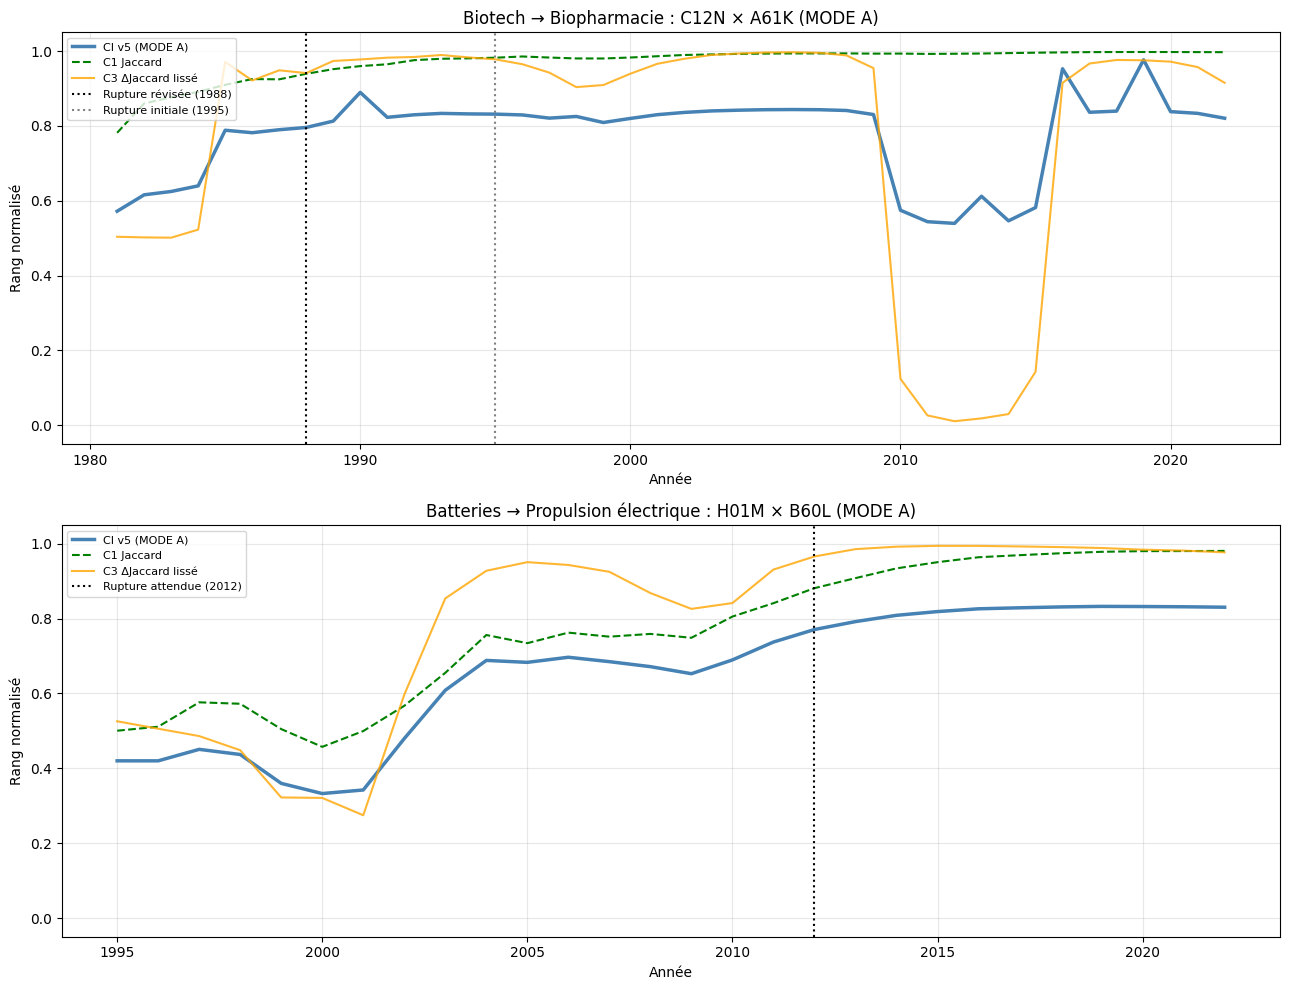

In [9]:
def plot_pair_v5(panel, ci, cj, label, breaks, ax=None):
    """
    breaks : liste de (année, label) pour afficher plusieurs ruptures
    """
    mask = (
        ((panel["cpc_i"]==ci) & (panel["cpc_j"]==cj)) |
        ((panel["cpc_i"]==cj) & (panel["cpc_j"]==ci))
    )
    sub = panel[mask].sort_values("year")
    if len(sub) == 0:
        print(f"⚠ Paire {ci}×{cj} absente")
        return
    if ax is None:
        _, ax = plt.subplots(figsize=(12,4))

    ax.plot(sub["year"], sub["CI_A"],   lw=2.5, color="steelblue", label="CI v5 (MODE A)")
    ax.plot(sub["year"], sub["C1_A"],   lw=1.5, color="green",  ls="--", label="C1 Jaccard")
    ax.plot(sub["year"], sub["C3_A"],   lw=1.5, color="orange", ls="-",  label="C3 ΔJaccard lissé", alpha=0.8)

    colors_break = ["black", "gray", "red"]
    for i, (yr, lbl) in enumerate(breaks):
        ax.axvline(yr, color=colors_break[i], ls=":", lw=1.5, label=lbl)

    ax.set_title(f"{label} : {ci} × {cj} (MODE A)")
    ax.set_xlabel("Année")
    ax.set_ylabel("Rang normalisé")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# C12N×A61K : deux ruptures testées
plot_pair_v5(panel, "C12N", "A61K",
             "Biotech → Biopharmacie",
             breaks=[(1988, "Rupture révisée (1988)"), (1995, "Rupture initiale (1995)")],
             ax=axes[0])

# H01M×B60L : rupture 2012 inchangée
plot_pair_v5(panel, "H01M", "B60L",
             "Batteries → Propulsion électrique",
             breaks=[(2012, "Rupture attendue (2012)")],
             ax=axes[1])

plt.tight_layout()
plt.savefig("validation_v5_modeA.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Top convergences (MODE A — rank par année)

In [10]:
def top_convergences_A(panel, year, n=10):
    """
    Top n paires les plus convergentes à une année donnée (MODE A).
    Inclut delta_jaccard pour vérifier que C3 discrimine bien
    les convergences actives des relations stables.
    """
    top = (
        panel[panel["year"]==year]
        .nlargest(n, "CI_A")[
            ["cpc_i","cpc_j","CI_A","C1_A","C3_A","C4_A",
             "jaccard","delta_jaccard","n_cooc"]
        ]
        .reset_index(drop=True)
    )
    # vérification taxonomique
    if (top["cpc_i"].str[:3] == top["cpc_j"].str[:3]).any():
        print("⚠ Paires taxonomiques présentes !")
    return top


for yr in [1990, 2000, 2010, 2020]:
    print(f"\n── Top 10 MODE A en {yr} ──────────────────────────")
    display(top_convergences_A(panel, yr))


── Top 10 MODE A en 1990 ──────────────────────────


,cpc_i,cpc_j,CI_A,C1_A,C3_A,C4_A,jaccard,delta_jaccard,n_cooc
0,G06Q,G07F,0.964372,1.000000,0.999195,0.755119,0.481928,0.101976,160
1,F02B,Y02T,0.957639,0.995977,0.984714,0.755119,0.295063,0.021924,514
2,F02D,Y02T,0.954086,0.983105,0.996782,0.755119,0.187218,0.052632,249
3,C21C,F27D,0.950988,0.980692,0.991150,0.755119,0.179688,0.032466,69
4,F22B,F23C,0.944502,0.971842,0.986323,0.755119,0.135838,0.022593,47
5,B01J,C10G,0.941899,0.969429,0.982301,0.755119,0.131986,0.019820,333
6,B82Y,C01P,0.940949,0.963797,0.989541,0.755119,0.120766,0.031351,82
7,G06F,H04L,0.936116,0.956557,0.987128,0.755119,0.114433,0.024706,111
8,G06T,H04N,0.935744,0.954143,0.990346,0.755119,0.112774,0.032155,113
9,H02M,Y02B,0.933307,0.948512,0.992759,0.755119,0.102439,0.034505,63



── Top 10 MODE A en 2000 ──────────────────────────


,cpc_i,cpc_j,CI_A,C1_A,C3_A,C4_A,jaccard,delta_jaccard,n_cooc
0,G06Q,G07F,0.989627,1.000000,0.990219,0.937017,0.476518,0.032567,416
1,G11B,H04N,0.981232,0.981835,0.996274,0.937017,0.144934,0.055385,618
2,G06F,H04L,0.968820,0.966465,0.984164,0.937017,0.108661,0.028226,340
3,G06T,H04N,0.968413,0.979972,0.958081,0.937017,0.137865,0.016789,430
4,H01Q,H04B,0.967193,0.959013,0.992548,0.937017,0.097854,0.036651,114
5,H03M,H04L,0.966141,0.968328,0.972054,0.937017,0.112939,0.021770,151
6,G01S,G08G,0.952030,0.935724,0.986027,0.937017,0.078829,0.029565,70
7,D04B,D10B,0.947350,0.998603,0.979041,0.690055,0.361194,0.025627,121
8,G11C,H03K,0.940407,0.944108,0.932930,0.937017,0.085376,0.012440,101
9,G06Q,H04L,0.939474,0.925943,0.963204,0.937017,0.072549,0.018229,111



── Top 10 MODE A en 2010 ──────────────────────────


,cpc_i,cpc_j,CI_A,C1_A,C3_A,C4_A,jaccard,delta_jaccard,n_cooc
0,H05B,H10K,0.934677,0.989422,0.997559,0.604408,0.163511,0.063230,475
1,C09K,H10K,0.933395,0.986710,0.998373,0.604408,0.140893,0.070051,410
2,B66B,D07B,0.932936,0.987524,0.995389,0.604408,0.149560,0.047816,51
3,C08K,C09D,0.930513,0.985896,0.990507,0.604408,0.137488,0.033909,728
4,C08L,C09D,0.928047,0.988337,0.978031,0.604408,0.153298,0.020595,1011
5,A46B,A61C,0.928034,0.980472,0.992406,0.604408,0.115873,0.040325,73
6,A61H,A63B,0.926474,0.979929,0.988337,0.604408,0.115192,0.029901,69
7,A45D,B26B,0.923201,0.972064,0.992135,0.604408,0.096721,0.038306,59
8,B41M,B42D,0.920193,0.970437,0.985354,0.604408,0.091703,0.027896,126
9,A47C,A61G,0.919817,0.984269,0.958774,0.604408,0.132399,0.013376,85



── Top 10 MODE A en 2020 ──────────────────────────


,cpc_i,cpc_j,CI_A,C1_A,C3_A,C4_A,jaccard,delta_jaccard,n_cooc
0,C21D,C22C,0.848040,0.999705,0.999705,0.0,0.382122,0.087271,2381
1,F02C,F05D,0.847954,0.999607,0.999607,0.0,0.379384,0.083237,4424
2,F01D,F05D,0.847722,1.000000,0.998135,0.0,0.638560,0.054805,7505
3,F01D,F02C,0.847405,0.999116,0.998724,0.0,0.281979,0.066319,3117
4,B22F,B33Y,0.847299,0.998233,1.000000,0.0,0.254267,0.163200,1475
5,B60Q,F21S,0.847127,0.998037,0.999804,0.0,0.237552,0.088672,854
6,G06F,H04L,0.846815,0.999411,0.996269,0.0,0.301839,0.041152,12341
7,B29C,B33Y,0.846381,0.996662,0.999902,0.0,0.181343,0.132821,2778
8,F01M,F16N,0.846356,0.997153,0.998920,0.0,0.199632,0.067445,217
9,C07G,C08H,0.846074,0.997938,0.996564,0.0,0.224199,0.043399,63


---
## Série temporelle (MODE B — panel cylindré)

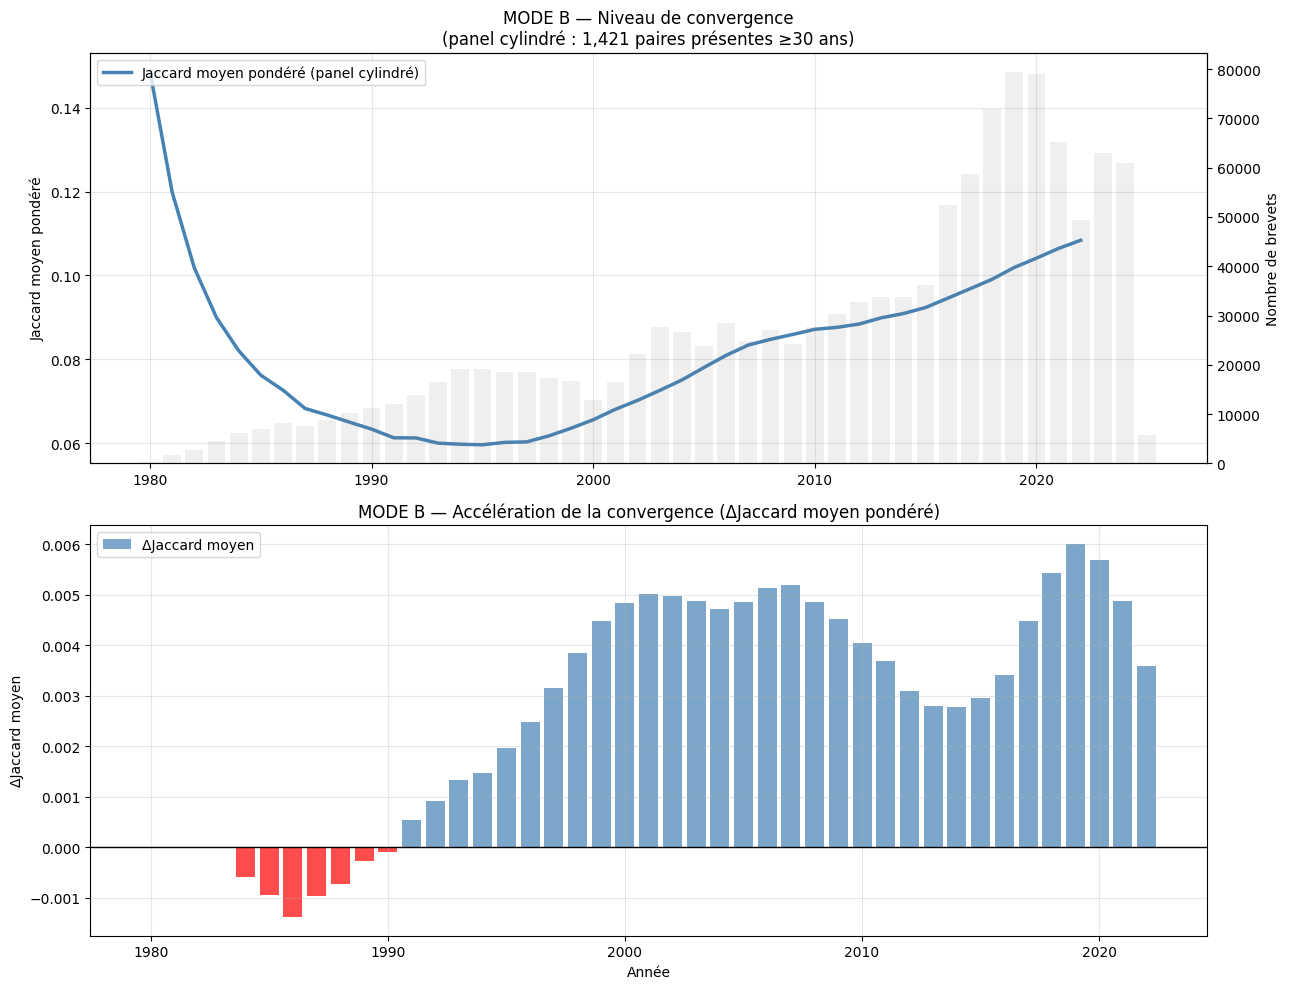


→ MODE B montre la tendance macroscopique sans biais de composition
  Le Jaccard moyen doit être croissant (espace technologique plus interconnecté)
  Le ΔJaccard moyen identifie les périodes d'accélération (bleu) et de ralentissement (rouge)


In [11]:
yearly_patents = pd.Series(brevet_count_by_year).rename("n_patents")

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# ── Graphique 1 : Jaccard moyen pondéré (niveau de convergence) ──
ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(CI_B_time["year"], CI_B_time["jaccard_moyen_pondere"],
         color="steelblue", lw=2.5, label="Jaccard moyen pondéré (panel cylindré)")
ax1b.bar(yearly_patents.index, yearly_patents.values,
         alpha=0.12, color="gray", label="Nb brevets")
ax1.set_title(f"MODE B — Niveau de convergence\n(panel cylindré : {len(stable_pairs):,} paires présentes ≥{MIN_YEARS_CYLINDRE} ans)")
ax1.set_ylabel("Jaccard moyen pondéré")
ax1b.set_ylabel("Nombre de brevets")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# ── Graphique 2 : ΔJaccard moyen (accélération) ─────────────────
ax2 = axes[1]
colors = ["steelblue" if v >= 0 else "red"
          for v in CI_B_time["delta_jaccard_moyen"]]
ax2.bar(CI_B_time["year"], CI_B_time["delta_jaccard_moyen"],
        color=colors, alpha=0.7, label="ΔJaccard moyen")
ax2.axhline(0, color="black", lw=1)
ax2.set_title("MODE B — Accélération de la convergence (ΔJaccard moyen pondéré)")
ax2.set_ylabel("ΔJaccard moyen")
ax2.set_xlabel("Année")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("serie_temporelle_v5_modeB.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ MODE B montre la tendance macroscopique sans biais de composition")
print("  Le Jaccard moyen doit être croissant (espace technologique plus interconnecté)")
print("  Le ΔJaccard moyen identifie les périodes d'accélération (bleu) et de ralentissement (rouge)")

---
## Comparaison des deux modes

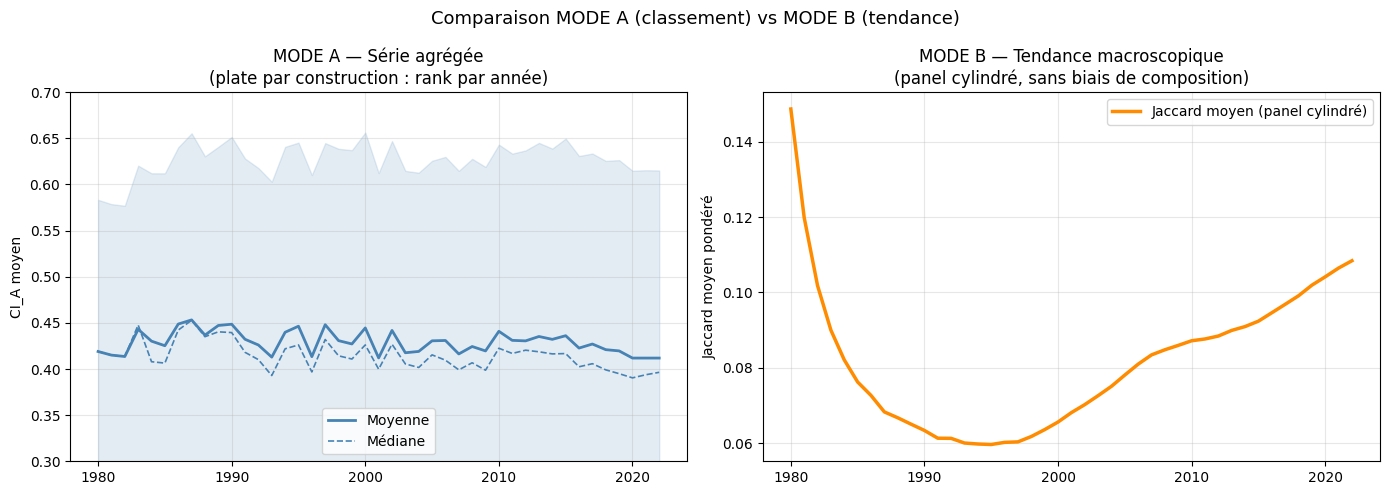

In [12]:
# Série temporelle MODE A (pour comparaison, elle devrait être quasi-plate)
CI_A_time = (
    panel.groupby("year")["CI_A"]
    .agg(["mean","median","std"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MODE A
axes[0].fill_between(CI_A_time.index,
    (CI_A_time["mean"]-CI_A_time["std"]).clip(0),
    (CI_A_time["mean"]+CI_A_time["std"]).clip(upper=1),
    alpha=0.15, color="steelblue")
axes[0].plot(CI_A_time.index, CI_A_time["mean"],   color="steelblue", lw=2, label="Moyenne")
axes[0].plot(CI_A_time.index, CI_A_time["median"], color="steelblue", lw=1.2, ls="--", label="Médiane")
axes[0].set_title("MODE A — Série agrégée\n(plate par construction : rank par année)")
axes[0].set_ylabel("CI_A moyen")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.3, 0.7)

# MODE B
axes[1].plot(CI_B_time["year"], CI_B_time["jaccard_moyen_pondere"],
             color="darkorange", lw=2.5, label="Jaccard moyen (panel cylindré)")
axes[1].set_title("MODE B — Tendance macroscopique\n(panel cylindré, sans biais de composition)")
axes[1].set_ylabel("Jaccard moyen pondéré")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Comparaison MODE A (classement) vs MODE B (tendance)", fontsize=13)
plt.tight_layout()
plt.savefig("comparaison_modes_v5.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Export final

In [ ]:
# Panel complet avec scores MODE A
cols_panel = [
    "cpc_i","cpc_j","year",
    "C1_A","C3_A","C4_A","CI_A",
    "jaccard","delta_jaccard","delta_jaccard_raw",
    "p_j_given_i","p_i_given_j","n_cooc","cluster_absorption"
]
panel[cols_panel].to_parquet("indice_convergence_v5_panel.parquet", index=False)

# Série temporelle MODE B
CI_B_time.to_csv("indice_convergence_v5_serie_B.csv", index=False)

# Panel cylindré
panel_B[cols_panel].to_parquet("indice_convergence_v5_cylindre.parquet", index=False)

print("Fichiers exportés :")
print(f"  indice_convergence_v5_panel.parquet     — {len(panel):,} lignes (panel complet, MODE A)")
print(f"  indice_convergence_v5_serie_B.csv       — {len(CI_B_time)} années (série temporelle MODE B)")
print(f"  indice_convergence_v5_cylindre.parquet  — {len(panel_B):,} lignes (panel cylindré MODE B)")